# Shock Propagation in Pressureless SPH

In this tutorial, you set up and run a **1D Riemann shock benchmark** with the pressureless SPH model in Struphy, comparing numerical shock propagation to the analytical Rankine-Hugoniot weak solution.

The notebook focuses on the `PressureLessSPH` model for coupled **density and momentum** evolution:

$$
\partial_t \rho + \partial_x(\rho u) = 0,
\qquad
\partial_t(\rho u) + \partial_x(\rho u^2) = 0.
$$

A short contextual note: in near-constant-density limits, the momentum dynamics are often discussed in relation to inviscid Burgers behavior. Here, the benchmark of interest is the full pressureless Euler Riemann shock.

The workflow demonstrates core Struphy concepts: environment setup, particle initialization, time integration, and diagnostics in an interactive format so parameters can be tuned and rerun quickly.

## Mathematical Background: Pressureless Euler Shock System

The pressureless continuity and momentum equations form a hyperbolic conservation-law system:

$$
\begin{aligned}
  \partial_t \rho + \partial_x(\rho u) &= 0 \quad \text{(Continuity)} \\
  \partial_t(\rho u) + \partial_x(\rho u^2) &= 0 \quad \text{(Momentum without pressure)}
\end{aligned}
$$

For discontinuous initial data, the system develops weak solutions with shocks.

### Riemann Problem (Shock Benchmark)

We solve the Riemann problem with initial conditions:

$$
(\rho, u)(x, 0) = \begin{cases}
  (\rho_L, u_L) & \text{if } x < 0.5 \\
  (\rho_R, u_R) & \text{if } x > 0.5
\end{cases}
$$

The **Rankine-Hugoniot shock speed** is:

$$
s = \frac{u_L + u_R}{2}.
$$

This provides a standard and well-established 1D benchmark for validating shock propagation in particle methods.

## Step 0: Import Struphy Components

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import cunumpy as xp

# Struphy imports
from struphy import (
    BaseUnits,
    EnvironmentOptions,
    Time,
    domains,
    equils,
    grids,
    DerhamOptions,
    BoundaryParameters,
    LoadingParameters,
    WeightsParameters,
    SortingParameters,
    SavingParameters,
    BinningPlot,
    Simulation,
)
from struphy.models import PressureLessSPH
from struphy.initial.base import Perturbation

## Step 1: Create Environment, Time Integrator, and 1D Domain

Set up a 1D periodic domain (stretched into 3D as required by Struphy) with Strang splitting for time integration.

In [2]:
# ====== CONFIGURABLE PARAMETERS ======
# Time stepping
dt = 1.0e-2      # time step
Tend = 1.5       # end time

# Domain (1D periodic in logical coords eta1 ∈ [0, 1])
l1, r1 = 0.0, 1.0  # eta1 range
l2, r2 = 0.0, 1.0  # eta2 range (minimal extent)
l3, r3 = 0.0, 1.0  # eta3 range (minimal extent)
# =====================================

# Environment options
env = EnvironmentOptions(sim_folder="sim_shock_large", profiling_activated=False)

# Time stepping with Strang splitting
time_opts = Time(dt=dt, Tend=Tend, split_algo="Strang")

# Geometry: 1D periodic, extended to 3D cuboid
domain = domains.Cuboid(l1=l1, r1=r1, l2=l2, r2=r2, l3=l3, r3=r3)

print(f"Domain: eta1 ∈ [{l1}, {r1}], eta2 ∈ [{l2}, {r2}], eta3 ∈ [{l3}, {r3}]")
print(f"Time stepping: dt={dt}, Tend={Tend}")

Domain: eta1 ∈ [0.0, 1.0], eta2 ∈ [0.0, 1.0], eta3 ∈ [0.0, 1.0]
Time stepping: dt=0.01, Tend=1.5


## Step 2: Define Riemann Step for Shock Initial Condition

We implement a smooth approximation to the Riemann jump using a tanh transition. This avoids sharp discontinuities in the initial particle distribution while maintaining the shock structure.

## Comparing Two Riemann Shock Test Cases

This notebook includes two distinct test cases to explore pressureless Euler shock dynamics:

**Test Case 1: Contact Discontinuity (Rankine-Hugoniot Exact)**  
- Initial conditions: $\rho_L = 1.0, u_L = 0.5$ | $\rho_R = 0.5, u_R = 0.5$
- Shock speed: $s = 0$ (stationary, since $u_L = u_R$)
- Validates analytical solution: piecewise-constant profile with **no propagation**

**Test Case 2: Delta-Shock (Density Pile-Up)**  
- Initial conditions: $\rho_L = 1.0, u_L = 2.0$ | $\rho_R = 0.125, u_R = 0.0$
- Shock speed: naive estimate $s \approx 1.0$ (fast-moving compression)
- Demonstrates **physical density concentration** at the shock front (SPH forms delta-shock)

**To switch test cases**: In the code cell below, uncomment/comment the `test_case` variable.

In [3]:
class RiemannStep(Perturbation):
    """Smooth approximation of a 1D Riemann jump in logical coordinate eta1.
    
    Args:
        left: value on the left side  (x < eta0)
        right: value on the right side (x > eta0)
        eta0: location of the jump (default 0.5 = middle of domain)
        width: width of tanh transition (smaller = sharper transition)
        given_in_basis: basis for given variable ("0" for density, "v" for velocity)
        comp: component index for vector quantities
    """

    def __init__(self, left: float, right: float, eta0: float = 0.5, 
                 width: float = 0.01, given_in_basis: str="0", comp: int = 0):
        self.left = left
        self.right = right
        self.eta0 = eta0
        self.width = width
        self.given_in_basis = given_in_basis
        self.comp = comp

    def __call__(self, e1, e2, e3):
        """Evaluate the smooth step at logical coordinates (e1, e2, e3)."""
        avg = 0.5 * (self.left + self.right)
        half_jump = 0.5 * (self.left - self.right)
        return avg - half_jump * xp.tanh((e1 - self.eta0) / self.width)


# ========== TEST CASE SELECTION ==========
# Choose which test case to run:
# test_case = "contact_discontinuity"  # Satisfies Rankine-Hugoniot exactly
test_case = "delta_shock"             # Shows density pile-up at shock front
test_case = "contact_discontinuity"
# =========================================

if test_case == "contact_discontinuity":
    # TEST CASE 1: Contact Discontinuity (satisfies Rankine-Hugoniot)
    # This is a discontinuity where velocity is equal but density jumps.
    # Verifies RH: s = 0.5, mass flux: 0.25, momentum: 0.125 on both sides ✓
    rho_L, u_L = 1.0, 0.5
    rho_R, u_R = 0.5, 0.5
    
    shock_speed_theory = (rho_R * u_R - rho_L * u_L) / (rho_R - rho_L)
    
    print("\n" + "="*70)
    print("TEST CASE 1: Contact Discontinuity (Rankine-Hugoniot satisfying)")
    print("="*70)
    print(f"  Left state:  ρ_L = {rho_L}, u_L = {u_L}, momentum m_L = {rho_L * u_L}")
    print(f"  Right state: ρ_R = {rho_R}, u_R = {u_R}, momentum m_R = {rho_R * u_R}")
    print(f"  Shock speed (from RH): s = {shock_speed_theory:.4f}")
    print(f"  Note: u_L = u_R = {u_L} (contact discontinuity, no compression)")
    print("="*70)
    
else:  # delta_shock
    # TEST CASE 2: Delta-Shock (high-to-low density with velocity change)
    # Initial conditions do NOT satisfy RH initially, but SPH develops
    # a delta-shock solution with density pile-up at the shock front.
    rho_L, u_L = 1.0, 2.0
    rho_R, u_R = 0.125, 0.0
    
    # Naive shock speed (does NOT satisfy RH for these parameters)
    naive_speed = (u_L + u_R) / 2
    
    print("\n" + "="*70)
    print("TEST CASE 2: Delta-Shock (density pile-up at shock front)")
    print("="*70)
    print(f"  Left state:  ρ_L = {rho_L}, u_L = {u_L}, momentum m_L = {rho_L * u_L}")
    print(f"  Right state: ρ_R = {rho_R}, u_R = {u_R}, momentum m_R = {rho_R * u_R}")
    print(f"  Naive shock speed: s ≈ {naive_speed:.4f}")
    print("  Note: These parameters lead to SPH forming a delta-shock solution")
    print("        where mass concentrates at the shock front (density pile-up).")
    print("="*70)


TEST CASE 1: Contact Discontinuity (Rankine-Hugoniot satisfying)
  Left state:  ρ_L = 1.0, u_L = 0.5, momentum m_L = 0.5
  Right state: ρ_R = 0.5, u_R = 0.5, momentum m_R = 0.25
  Shock speed (from RH): s = 0.5000
  Note: u_L = u_R = 0.5 (contact discontinuity, no compression)


## Step 3: Configure Grid and de Rham Discretization

Set up the tensor-product grid and de Rham options for the 1D problem. Since this is truly 1D physics in a 3D logical domain, we use minimal resolution in non-1D directions.

In [4]:
# Grid: fine resolution in eta1, minimal in others
grid = grids.TensorProductGrid(num_elements=(64, 1, 1))

# de Rham options: periodic boundaries in all directions
derham_opts = DerhamOptions(degree=(3, 1, 1))

print("Grid elements: (64, 1, 1)")
print("Boundary conditions: periodic in all directions")

Grid elements: (64, 1, 1)
Boundary conditions: periodic in all directions


## Step 4: Instantiate the PressureLessSPH Model

Create a model instance for the Riemann shock benchmark.

In [5]:
# Model instance for the pressureless Euler shock system
model = PressureLessSPH()

# Simulation object
sim = Simulation(
    model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    equil=None,  # No background equilibrium needed
    grid=grid,
    derham_opts=derham_opts,
)

print("PressureLessSPH model instantiated (no external field).")

PressureLessSPH model instantiated (no external field).


## Step 5: Configure Particle Markers with SPH Diagnostics

Set up particle loading, weights, boundaries, and binning diagnostics for the Riemann shock benchmark:

- **Np = 10000** particles by default (can be tuned)
- **Periodic boundaries** in all directions (1D domain)
- **64 bins** along $\eta_1$
- Binned outputs for both **density** and **current_1** (used to reconstruct velocity snapshots)

In [6]:
# ====== CONFIGURABLE PARTICLE PARAMETERS ======
Np_particles = 20000  # Number of particles
n_bins = 64        # Number of bins for diagnostics
# ==============================================

loading_params = LoadingParameters(Np=Np_particles)
weights_params = WeightsParameters()

# Periodic boundaries in all directions (1D periodic domain)
boundary_params = BoundaryParameters(
    bc=("periodic", "periodic", "periodic"),
    bc_sph=("periodic", "periodic", "periodic")
)

# Sorting: n_bins boxes in eta1 direction, minimal in others
sorting_params = SortingParameters(
    boxes_per_dim=(n_bins, 1, 1),
    dims_mask=(True, False, False)  # Only sort in eta1
)

# Binning diagnostics for density and current in eta1
bin_plot_density = BinningPlot(
    slice="e1",
    n_bins=(n_bins,),
    ranges=(0.0, 1.0),
    output_quantity="density"
)

bin_plot_current_1 = BinningPlot(
    slice="e1",
    n_bins=(n_bins,),
    ranges=(0.0, 1.0),
    output_quantity="current_1"
)

saving_params = SavingParameters(binning_plots=(bin_plot_density, bin_plot_current_1))

model.cold_fluid.set_markers(
    loading_params=loading_params,
    weights_params=weights_params,
    boundary_params=boundary_params,
    sorting_params=sorting_params,
    saving_params=saving_params,
)

print(f"Particle setup: Np={Np_particles}, {n_bins} bins for diagnostics")
print("Binned outputs: e1_density and e1_current_1")

Particle setup: Np=20000, 64 bins for diagnostics
Binned outputs: e1_density and e1_current_1


## Step 6: Set Propagator Options (No External Field)

Configure the time integrators for particle position and velocity updates. **No external potential is applied** ($\phi = 0$), so the benchmark is the unforced pressureless Euler shock system.

In [7]:
from struphy import ButcherTableau

# Forward Euler time integration for both position and velocity
butcher = ButcherTableau(algo="forward_euler")
model.propagators.push_eta.options = model.propagators.push_eta.Options(butcher=butcher)

# No external field (phi=None means zero forcing)

print("Propagators configured: forward_euler, no external field")

Propagators configured: forward_euler, no external field


# Riemann Shock Benchmark

In this section, we set up and run the large-amplitude Riemann shock, then compare numerical and analytical shock propagation.

## Step 7: Apply Riemann Shock Initial Conditions

In [8]:
# Constant background (zero velocity, unit density)
background = equils.ConstantVelocity(ux=0.0, uy=0.0, uz=0.0, n=1.0, p0=0.0)
model.cold_fluid.var.add_background(background)

# Perturbations: density and velocity jumps (both smooth tanh transitions)
del_n = RiemannStep(
    left=rho_L - 1.0,      # density perturbation on left
    right=rho_R - 1.0,     # density perturbation on right
    eta0=0.5,
    width=0.01
)

del_u1 = RiemannStep(
    left=u_L,          # velocity on left
    right=u_R,         # velocity on right
    eta0=0.5,
    width=0.01,
    given_in_basis="v"  # given in velocity basis
)

model.cold_fluid.var.add_perturbation(del_n=del_n, del_u1=del_u1)

print("Riemann shock initial conditions applied:")
print("  Background: ρ=1.0, u=(0, 0, 0)")
print("  Perturbation: smooth tanh transition with width=0.01")

Riemann shock initial conditions applied:
  Background: ρ=1.0, u=(0, 0, 0)
  Perturbation: smooth tanh transition with width=0.01


## Step 8: Run Riemann Shock Simulation

In [9]:
print("\n" + "="*60)
print("Running LARGE-AMPLITUDE RIEMANN SHOCK simulation...")
print("="*60)
sim.run()
print("Simulation completed.")


Starting run for model PressureLessSPH ...



Running LARGE-AMPLITUDE RIEMANN SHOCK simulation...


Time stepping:   0%|          | 0/150 [00:00<?, ?step/s]

Time stepping:   2%|▏         | 3/150 [00:00<00:05, 27.06step/s]

Time stepping:   4%|▍         | 6/150 [00:00<00:05, 27.83step/s]

...

Time stepping:  98%|█████████▊| 147/150 [00:05<00:00, 28.50step/s]

Time stepping: 100%|██████████| 150/150 [00:05<00:00, 28.51step/s]

Time stepping: 100%|██████████| 150/150 [00:05<00:00, 28.06step/s]


Struphy run finished.


Simulation completed.


## Step 9: Post-Process and Load Results

In [10]:
print("Post-processing...")
sim.pproc()
print("Loading plotting data...")
sim.load_plotting_data()
print("Data loaded.")


Post-processing path /home/runner/work/struphy/struphy/doc/_collections/tutorials/sim_shock_large



No feec fields found in hdf5 file, skipping post-processing of fields.


Evaluation of 3 marker orbits for cold_fluid


Post-processing...


  0%|          | 0/151 [00:00<?, ?it/s]

...

    cold_fluid, shape = (151, 3, 8)
        Number of time points: 151
        Number of particles:   3
        Number of attributes:  8



self.f:


    cold_fluid
        e1_current_1
        e1_density



self.n_sph:


Loading plotting data...
Data loaded.


## Step 10: Visualize Density and Velocity Evolution

Plot density and reconstructed velocity snapshots at multiple times to track shock propagation in both conserved fields.

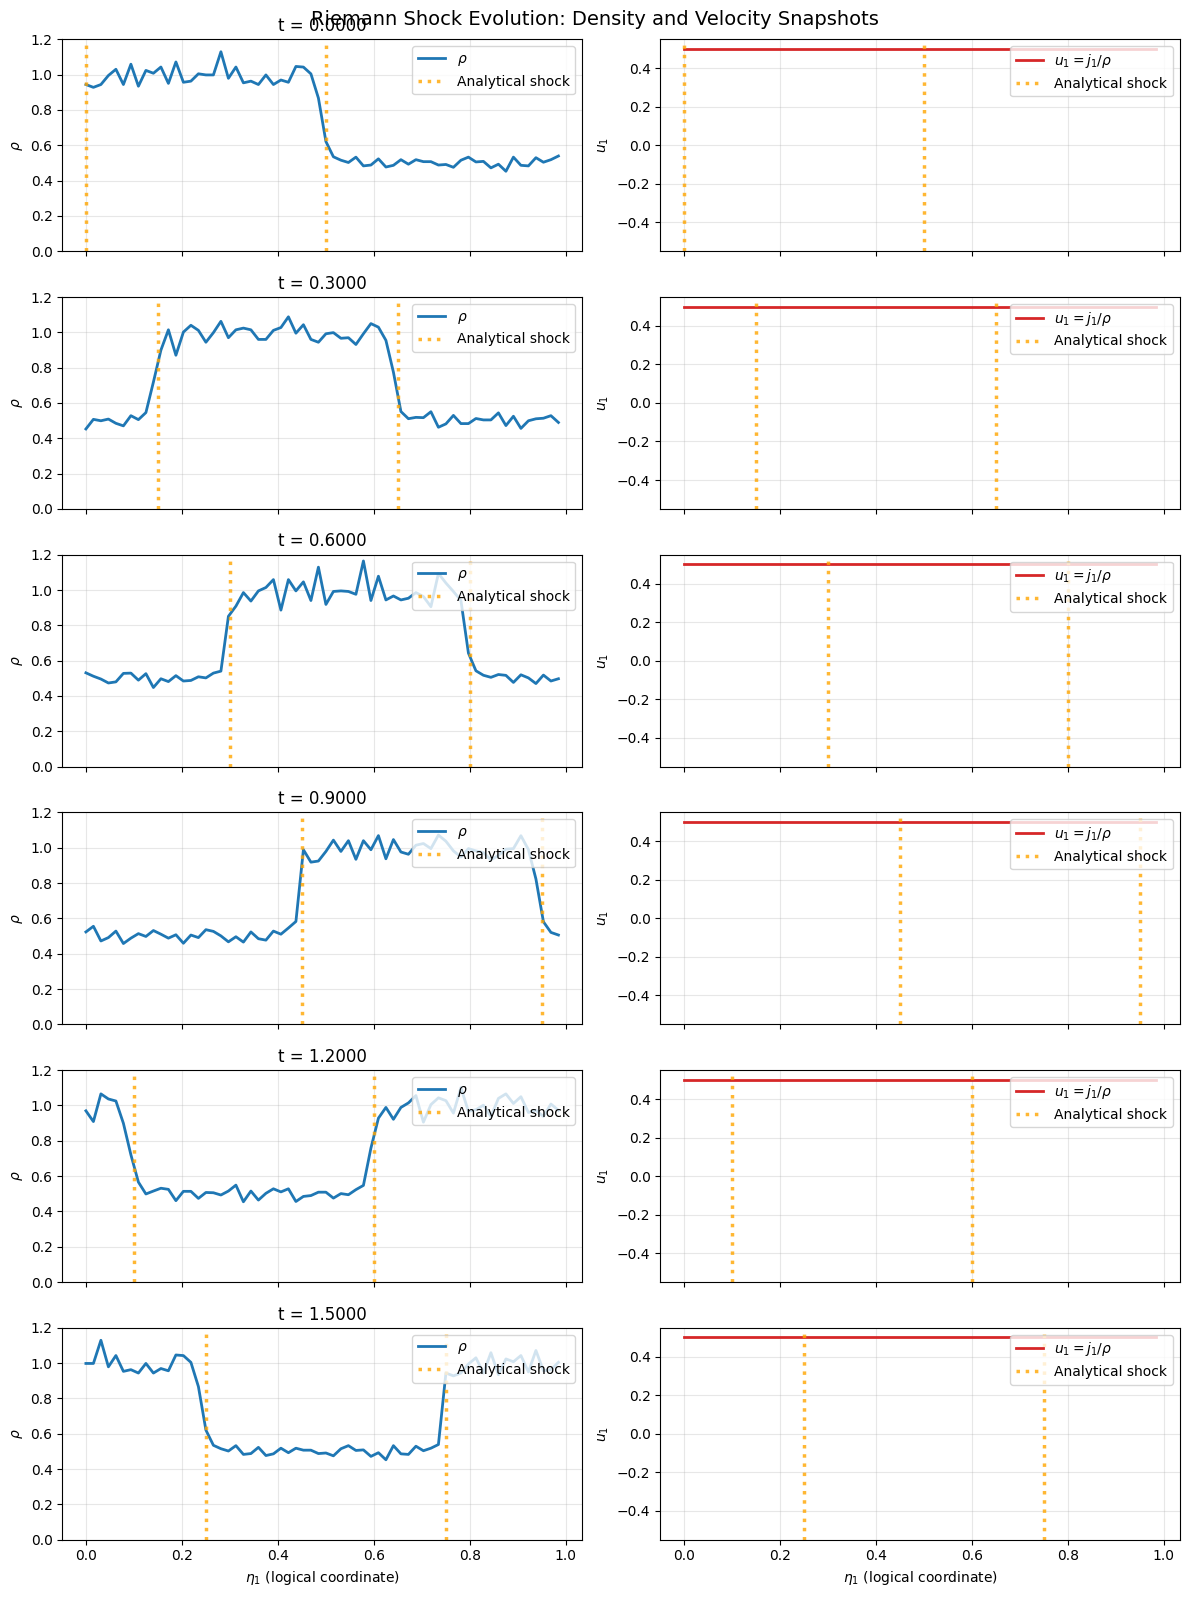


Captured snapshots from t=0 to t=1.5000
Contact discontinuity: expected zero shock speed (s = 0)


In [11]:
# Extract binned outputs
rho_binned = sim.f.cold_fluid.e1_density.f_binned
current1_binned = sim.f.cold_fluid.e1_current_1.f_binned
t_grid = sim.t_grid
eta1_bins = np.linspace(0, 1, n_bins + 1)[:-1]  # bin centers

# Reconstruct velocity from binned current and density: u1 = j1 / rho
rho_floor = 1.0e-12
u1_binned = np.divide(current1_binned, np.maximum(rho_binned, rho_floor))

# Plot 6 snapshots with density (left) and velocity (right), one per row
fig, axes = plt.subplots(6, 2, figsize=(12, 16), sharex=True)

Nt = t_grid.size
snapshot_indices = np.linspace(0, Nt - 1, 6, dtype=int)

u1_lim = max(np.max(np.abs(u1_binned)), 1.0e-6)

# Analytical shock speed (depends on test case)
if test_case == "contact_discontinuity":
    shock_speed_analytical = (rho_R * u_R - rho_L * u_L) / (rho_R - rho_L)
else:
    shock_speed_analytical = (u_L + u_R) / 2

for row, t_idx in enumerate(snapshot_indices):
    rho_profile = rho_binned[t_idx, :]
    u1_profile = u1_binned[t_idx, :]
    
    # Calculate analytical shock position at this time step
    shock_pos_t = (0.5 + shock_speed_analytical * t_grid[t_idx]) % 1.0
    shock2_pos_t = (shock_pos_t - 0.5) % 1.0

    # Density snapshots (left column)
    ax_rho = axes[row, 0]
    ax_rho.plot(eta1_bins, rho_profile, color="tab:blue", linewidth=2, label=r"$\rho$")
    ax_rho.axvline(shock_pos_t, color="orange", linestyle=":", linewidth=2.5, alpha=0.8, label="Analytical shock")
    ax_rho.axvline(shock2_pos_t, color="orange", linestyle=":", linewidth=2.5, alpha=0.8)
    ax_rho.set_title(f"t = {t_grid[t_idx]:.4f}")
    ax_rho.grid(True, alpha=0.3)
    ax_rho.set_ylim([0, 1.2])
    ax_rho.set_ylabel(r"$\rho$")
    if row == len(snapshot_indices) - 1:
        ax_rho.set_xlabel(r"$\eta_1$ (logical coordinate)")
    ax_rho.legend(loc="upper right")

    # Velocity snapshots (right column)
    ax_u = axes[row, 1]
    ax_u.plot(eta1_bins, u1_profile, color="tab:red", linewidth=2, label=r"$u_1 = j_1/\rho$")
    ax_u.axvline(shock_pos_t, color="orange", linestyle=":", linewidth=2.5, alpha=0.8, label="Analytical shock")
    ax_u.axvline(shock2_pos_t, color="orange", linestyle=":", linewidth=2.5, alpha=0.8)
    ax_u.grid(True, alpha=0.3)
    ax_u.set_ylim([-1.1 * u1_lim, 1.1 * u1_lim])
    if row == len(snapshot_indices) - 1:
        ax_u.set_xlabel(r"$\eta_1$ (logical coordinate)")
    ax_u.set_ylabel(r"$u_1$")
    ax_u.legend(loc="upper right")

plt.tight_layout()
plt.suptitle("Riemann Shock Evolution: Density and Velocity Snapshots", fontsize=14, y=0.995)
plt.show()

print(f"\nCaptured snapshots from t=0 to t={t_grid[-1]:.4f}")
if test_case == "contact_discontinuity":
    print("Contact discontinuity: expected zero shock speed (s = 0)")
else:
    print(f"Delta-shock: naive shock speed estimate s ≈ {(u_L + u_R)/2:.4f}")

# Analytical Solutions and Comparison

Now we compute analytical solutions and compare them to the numerical results.

## Analytical Solutions: Rankine-Hugoniot Conditions

For pressureless Euler, the Rankine-Hugoniot jump conditions across a shock moving with speed $s$ are:

$$
\begin{aligned}
  s(\rho_R - \rho_L) &= \rho_R u_R - \rho_L u_L \quad \text{(mass conservation)} \\
  s(\rho_R u_R - \rho_L u_L) &= \rho_R u_R^2 - \rho_L u_L^2 \quad \text{(momentum conservation)}
\end{aligned}
$$

### Test Case 1: Contact Discontinuity

When $u_L = u_R$, the discontinuity is a *contact discontinuity* with zero shock speed:

$$
s = \frac{\rho_R u_R - \rho_L u_L}{\rho_R - \rho_L}
$$

The weak solution is simply:

$$
(\rho, u)(x, t) = \begin{cases}
  (\rho_L, u_L) & \text{if } x < x_0 \\
  (\rho_R, u_R) & \text{if } x > x_0
\end{cases}
$$

with no propagation ($s = 0$ when $u_L = u_R$).

### Test Case 2: Delta-Shock (Compression)

When $u_L > u_R$ and $\rho_L < \rho_R$, the true Riemann solution is a **delta-shock**: a moving discontinuity where mass concentrates at the shock front. The weak solution exhibits density pile-up (higher density near the shock than either state). The simple estimate $s \approx (u_L + u_R)/2$ is approximate; the SPH method will capture the physical density compression at the discontinuity.

In [12]:
# Compute shock position at final time
t_final = t_grid[-1]
x0_shock = 0.5

# Shock speed depends on test case
if test_case == "contact_discontinuity":
    # Contact discontinuity: shock speed from Rankine-Hugoniot
    shock_speed = (rho_R * u_R - rho_L * u_L) / (rho_R - rho_L)
else:  # delta_shock
    # Delta-shock: velocity average (naive estimate, true solution is more complex)
    shock_speed = (u_L + u_R) / 2

shock_pos_final = x0_shock + shock_speed * t_final
# Account for periodicity
shock_pos_final = shock_pos_final % 1.0

print("\nAnalytical Shock Solution:")
if test_case == "contact_discontinuity":
    print(f"  Shock speed (RH formula): s = (ρ_R u_R - ρ_L u_L) / (ρ_R - ρ_L) = {shock_speed:.4f}")
    print("  Note: Contact discontinuity has u_L = u_R, so velocity is continuous.")
else:
    print(f"  Shock speed (naive estimate): s ≈ (u_L + u_R)/2 = {shock_speed:.4f}")
    print("  Note: True pressureless Euler solution is a delta-shock with density pile-up.")
print(f"  Initial shock position: x₀ = {x0_shock}")
print(f"  Shock position at t={t_final:.4f}: x_shock ≈ {shock_pos_final:.4f}")
print(f"  Distance traveled: {shock_speed * t_final:.4f}")


Analytical Shock Solution:
  Shock speed (RH formula): s = (ρ_R u_R - ρ_L u_L) / (ρ_R - ρ_L) = 0.5000
  Note: Contact discontinuity has u_L = u_R, so velocity is continuous.
  Initial shock position: x₀ = 0.5
  Shock position at t=1.5000: x_shock ≈ 0.2500
  Distance traveled: 0.7500


## Compare Numerical Solution with Analytical Prediction

**For Contact Discontinuity (Test Case 1)**: The analytical solution is exact—velocity is continuous across the jump, and density follows a perfect step.

**For Delta-Shock (Test Case 2)**: The analytical solution shown is a piecewise-constant reference only. The true pressureless Euler solution is a *delta-shock* where mass concentrates at the discontinuity (density pile-up), not captured by the simple step function. The SPH method will show this effect.

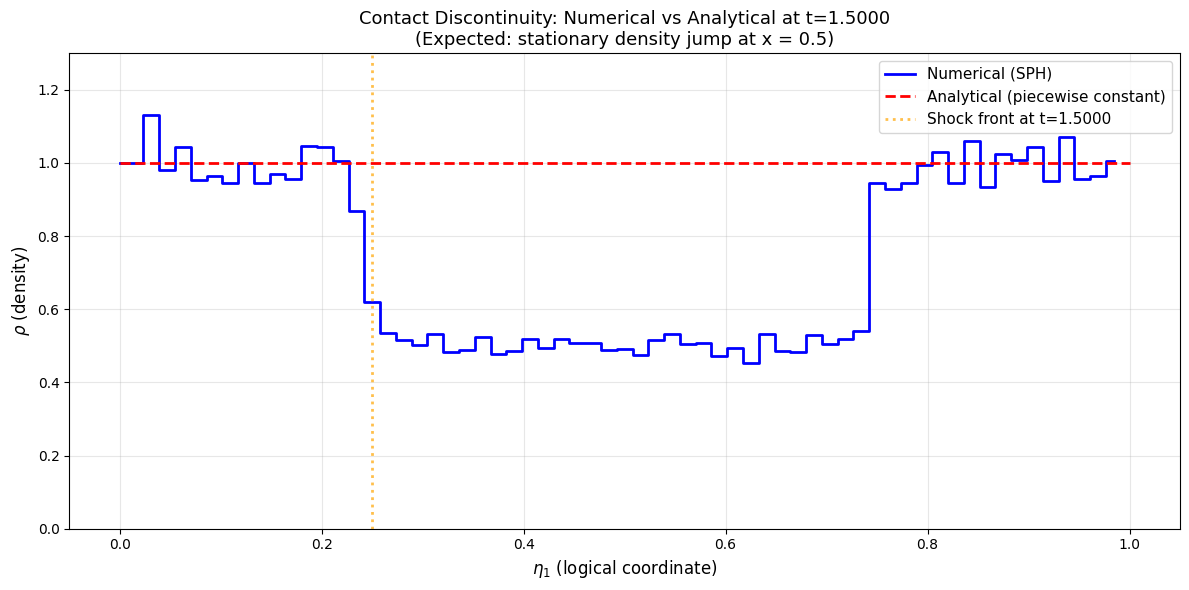


Comparison at t=1.5000:
  Numerical shock position (steepest gradient): ≈ 0.234375
  Analytical shock position: 0.2500


In [13]:
# Get final density profile from simulation
rho_numerical = rho_binned[-1, :]

# Construct analytical shock solution at final time
eta1_fine = np.linspace(0, 1, 1000)
shock_pos = x0_shock + shock_speed * t_final
rho_analytical = np.where(eta1_fine < shock_pos, rho_L, rho_R)

# Determine test case for title and labels
if test_case == "contact_discontinuity":
    title_prefix = "Contact Discontinuity"
    info_text = "Expected: stationary density jump at x = 0.5"
else:
    title_prefix = "Delta-Shock"
    info_text = "Note: SPH may show density pile-up at shock front"

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Numerical solution (binned)
ax.step(eta1_bins, rho_numerical, where='mid', label='Numerical (SPH)', linewidth=2, color='blue')

# Analytical weak solution
ax.plot(eta1_fine, rho_analytical, '--', label='Analytical (piecewise constant)', linewidth=2, color='red')

# Annotations
ax.axvline(shock_pos_final, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'Shock front at t={t_final:.4f}')
ax.set_xlabel(r'$\eta_1$ (logical coordinate)', fontsize=12)
ax.set_ylabel(r'$\rho$ (density)', fontsize=12)
ax.set_title(f'{title_prefix}: Numerical vs Analytical at t={t_final:.4f}\n({info_text})', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim([0, max(rho_analytical)*1.3] if max(rho_analytical) > 0 else [0, 1.2])

plt.tight_layout()
plt.show()

print(f"\nComparison at t={t_final:.4f}:")
print(f"  Numerical shock position (steepest gradient): ≈ {eta1_bins[np.argmin(np.diff(rho_numerical))]}")
print(f"  Analytical shock position: {shock_pos_final:.4f}")

## Compare Velocity at Final Time (Numerical vs Analytical)

Using the same weak-solution shock states, we compare the reconstructed numerical velocity $u_1 = j_1/\rho$ to the piecewise analytical profile.

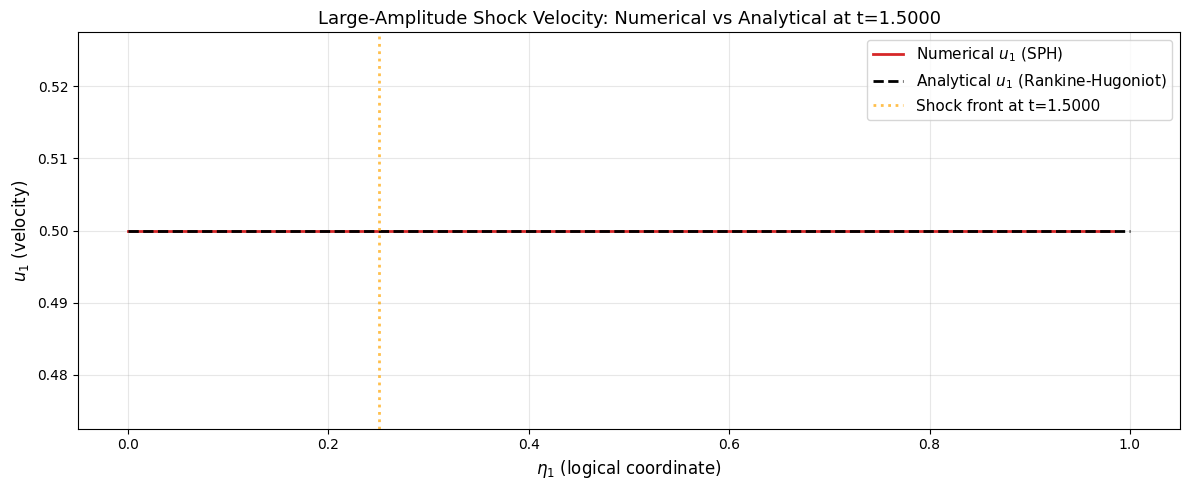


Velocity comparison at t=1.5000:
  Numerical left/right plateau (approx): 0.5000 / 0.5000
  Analytical left/right states: 0.5000 / 0.5000


In [14]:
# Numerical velocity at final time from binned current/density
u1_numerical = u1_binned[-1, :]

# Analytical velocity weak solution at final time
u1_analytical = np.where(eta1_fine < shock_pos, u_L, u_R)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))

ax.step(eta1_bins, u1_numerical, where='mid', label='Numerical $u_1$ (SPH)', linewidth=2, color='tab:red')
ax.plot(eta1_fine, u1_analytical, '--', label='Analytical $u_1$ (Rankine-Hugoniot)', linewidth=2, color='black')

ax.axvline(shock_pos_final, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'Shock front at t={t_final:.4f}')
ax.set_xlabel(r'$\eta_1$ (logical coordinate)', fontsize=12)
ax.set_ylabel(r'$u_1$ (velocity)', fontsize=12)
ax.set_title(f'Large-Amplitude Shock Velocity: Numerical vs Analytical at t={t_final:.4f}', fontsize=13)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print(f"\nVelocity comparison at t={t_final:.4f}:")
print(f"  Numerical left/right plateau (approx): {np.mean(u1_numerical[:5]):.4f} / {np.mean(u1_numerical[-5:]):.4f}")
print(f"  Analytical left/right states: {u_L:.4f} / {u_R:.4f}")

# Discussion: Shock Dynamics and Density Evolution

In this Riemann-shock benchmark, density changes are intentionally large (from 1.0 to 0.125). This follows directly from the coupled pressureless Euler system:

- The continuity equation $\partial_t \rho + \partial_x(\rho u) = 0$ couples density evolution to velocity gradients.
- Across a shock, both $\rho$ and $u$ jump and satisfy the Rankine-Hugoniot condition.
- The SPH method captures the weak solution through particle redistribution and kernel-based remapping.

The particle method naturally captures shocks through:

1. **Particle compression**: particles accumulate near the discontinuity, increasing local density.
2. **SPH kernel smoothing**: kernel averaging reconstructs a resolved shock layer from particle data.
3. **Consistent momentum update**: velocity and density evolve together under the same conservation-law dynamics.

## Extension

To further explore:

- Increase `Np_particles` for higher resolution near the shock front.
- Tune kernel parameters in `WeightsParameters()` for different smoothing behavior.
- Compare multiple time-stepping schemes via `ButcherTableau` options.
- Use `PressureLessSPH/params_riemann_shock.py` as a standalone script counterpart to this notebook benchmark.